In [20]:
from typing import Annotated, List,TypedDict
import operator

from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown

from langgraph.types import Send
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import START, END, StateGraph
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents.structured_output import ToolStrategy, ProviderStrategy
from langchain.agents import create_agent

from utils import get_chat, load_pdf

In [21]:
client = MultiServerMCPClient(
    {
        "papers": {
            "transport": "http",
            "url": "http://localhost:8000/mcp",
        }
    }
)

tools = await client.get_tools()

In [22]:
# Schema for structured output to use as an output.
class Review(BaseModel):
    """Write information about the paper. 
    All fields **MUST** be in the paper's original language; the **SOLE EXCEPTION** is the `overall_review`, wich must be in Portuguese."""

    area: str = Field(description="The paper's main area of research.")
    problem: str = Field(description="what problem does the article propose to solve?")
    step_by_step: list[str] = Field(description="Step by step list on how to solve the identified problem.")
    conclusion: str = Field(description="A conclusion about the paper's process.")
    overall_review: str = Field(description="An in-depth review of the paper in markdown format; point out the positives, negatives and research gaps.")


llm = get_chat("main_language_model")

reviewer_agent = create_agent(
        model=llm,
        tools=tools,
        response_format=Review
        )

In [23]:
BASE_SYS_PROMPT = """You are {reviewer_type}, and you must review a user-provided paper.
You may use tools to access other papers for examples and additional information.
{extra_info}"""

reviewer_type = "an nice reviewer"
extra_info = "Be nice about the text; focus mostly on its favorable aspects while still being unbiased and scientificly rigorous."
NICE_REVIEWER = BASE_SYS_PROMPT.format(reviewer_type=reviewer_type, extra_info=extra_info)

reviewer_type = "a strict reviewer"
extra_info = "Be strict about the text; focus on the possible gaps in the research while still being fair, unbiased, and scientificly rigorous."
STRICT_REVIEWER = BASE_SYS_PROMPT.format(reviewer_type=reviewer_type, extra_info=extra_info)

reviewer_type = "a neutral reviewer"
extra_info = "Be neutral about the text; be fair, unbiased, and scientificly rigorous while avoiding very strong opinions."
NEUTRAL_REVIEWER = BASE_SYS_PROMPT.format(reviewer_type=reviewer_type, extra_info=extra_info)


EDITOR = """You are an editor agent. You will be provided a paper and three different reviews. You must use the three given reviews to synthesize your own final review.
You may use tools to access other papers for examples and additional information."""

In [24]:
# Graph state
class State(TypedDict):
    paper_text: str
    nice_review: Review
    strict_review: Review
    neutral_review: Review
    final_review: Review

In [25]:
# Nodes
def nice_reviewer(state: State):
    """An agent that provides a nicer review to a paper"""

    # Generate queries
    review = reviewer_agent.invoke(
        {"messages":[
            SystemMessage(content=NICE_REVIEWER),
            HumanMessage(content=state["paper_text"]),
        ]}
    )['structured_response']

    return {"nice_review": review}



def strict_reviewer(state: State):
    """An agent that provides a more strict review to a paper"""

    # Generate queries
    review = reviewer_agent.invoke(
        {"messages":[
            SystemMessage(content=STRICT_REVIEWER),
            HumanMessage(content=state["paper_text"]),
        ]}
    )['structured_response']

    return {"strict_review": review}



def neutral_reviewer(state: State):
    """An agent that provides a neutral review to a paper"""

    # Generate queries
    review = reviewer_agent.invoke(
        {"messages":[
            SystemMessage(content=NEUTRAL_REVIEWER),
            HumanMessage(content=state["paper_text"]),
        ]}
    )['structured_response']

    return {"neutral_review": review}



def editor(state: State):
    """Synthesize final report from individual reviews"""


    reviews = f"""REVIEWER ONE:
    {state['nice_review']}

    -------------------
    
    REVIEWER TWO:
    {state['strict_review']}

    -------------------

    REVIEWER THREE:
    {state['neutral_review']}
    """

    final_review = reviewer_agent.invoke(
        {"messages":[
            SystemMessage(content=EDITOR),
            HumanMessage(content=f"# Paper\n{state["paper_text"]}"),
            HumanMessage(content=f"# Reviews\n{reviews}"),
        ]}
    )['structured_response']

    return {"final_review": final_review}


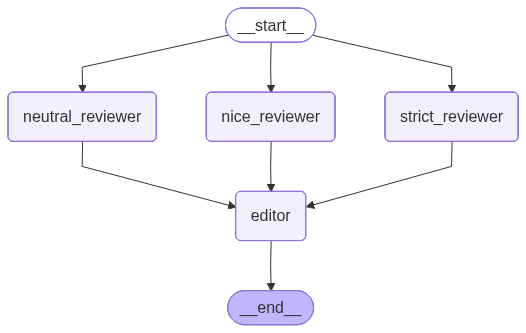

In [26]:
# Build workflow
reviewer_builder = StateGraph(State)

# Add the nodes
reviewer_builder.add_node("nice_reviewer", nice_reviewer)
reviewer_builder.add_node("strict_reviewer", strict_reviewer)
reviewer_builder.add_node("neutral_reviewer", neutral_reviewer)
reviewer_builder.add_node("editor", editor)

# Add edges to connect nodes
reviewer_builder.add_edge(START, "nice_reviewer")
reviewer_builder.add_edge(START, "strict_reviewer")
reviewer_builder.add_edge(START, "neutral_reviewer")
reviewer_builder.add_edge(
    ["nice_reviewer", "strict_reviewer", "neutral_reviewer"],
    "editor")
reviewer_builder.add_edge("editor", END)

# Compile the workflow
reviewer = reviewer_builder.compile()

# Show the workflow
display(Image(reviewer.get_graph().draw_mermaid_png()))

In [27]:
import os
from random import choice

TEST_DIR = "test-papers/"

title, text, metadata = load_pdf(TEST_DIR + choice(os.listdir(TEST_DIR)), chunck_size=0)

In [28]:
# Invoke
state = reviewer.invoke({"paper_text": text})

KeyError: 'structured_response'

In [ ]:
state["strict_review"].overall_review

'## Revisão Aprofundada: Conditional Memory via Scalable Lookup: A New Axis of Sparsity for Large Language Models\n\nEste artigo propõe uma contribuição significativa para o campo dos Modelos de Linguagem Grandes (LLMs) ao introduzir o conceito de '

In [ ]:
Markdown(state["strict_review"].overall_review)

## Revisão Aprofundada: Conditional Memory via Scalable Lookup: A New Axis of Sparsity for Large Language Models

Este artigo propõe uma contribuição significativa para o campo dos Modelos de Linguagem Grandes (LLMs) ao introduzir o conceito de 